In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
df = pd.read_csv('dev.csv')

In [5]:
df['Class'] = df['Class'].map({4: 0, 2: 1})

In [6]:
x = df.drop(['Sample code number', 'Uniformity of Cell Shape', 'Mitoses', 'Class'], axis=1).values
y = df['Class'].values
print(x)
print(y)

[[ 5  1  1 ...  1  3  1]
 [ 5  4  5 ... 10  3  2]
 [ 3  1  1 ...  2  3  1]
 ...
 [ 5 10  3 ...  3  8 10]
 [ 4  8  4 ...  4 10  6]
 [ 4  8  5 ...  5 10  4]]
[1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 0 1 1 0 1 0 0 1 1 0 1 1 1 1 1 1 0 1 1 1 0 1
 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 1 1 0 1 0 0 1
 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0
 0 1 1 1 0 1 1 1 1 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 0
 0 1 1 0 1 1 0 0 1 1 1 1 0 0 1 1 1 1 1 0 0 0 1 0 1 0 1 1 1 0 0 1 0 0 0 1 0
 0 1 1 1 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1 0 0 1 0 0 0 1 1 0 1 1 0 0 0 0 1 0 0
 1 0 0 0 1 0 1 0 0 0 0 1 1 1 1 1 1 0 0 1 1 0 1 0 0 0 1 1 1 1 0 0 0 0 0 1 0
 0 0 1 0 1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 0 1 0 1 0 0 1 1
 0 1 1 1 0 1 1 0 0 1 1 0 1 0 1 1 0 1 0 0 0 1 1 0 0 1 0 1 1 0 0 1 1 1 0 1 1
 1 0 0 1 1 1 0 1 1 0 0 0 0 0 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 1 1 1 0
 1 1 1 0 1 0 1 1 1 

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=24, stratify=y)

In [8]:
tree = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0)
tree.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
y_pred = tree.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

[[48  0]
 [ 3 86]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        48
           1       1.00      0.97      0.98        89

    accuracy                           0.98       137
   macro avg       0.97      0.98      0.98       137
weighted avg       0.98      0.98      0.98       137

Accuracy: 0.9781021897810219
Confusion Matrix:
 [[48  0]
 [ 3 86]]


Text(0.5, 1.0, 'Confusion Matrix')

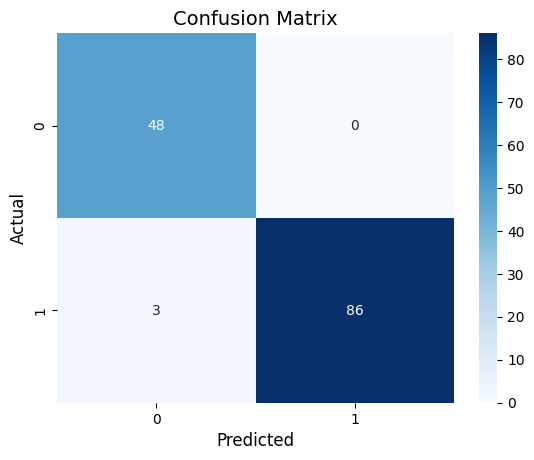

In [10]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)

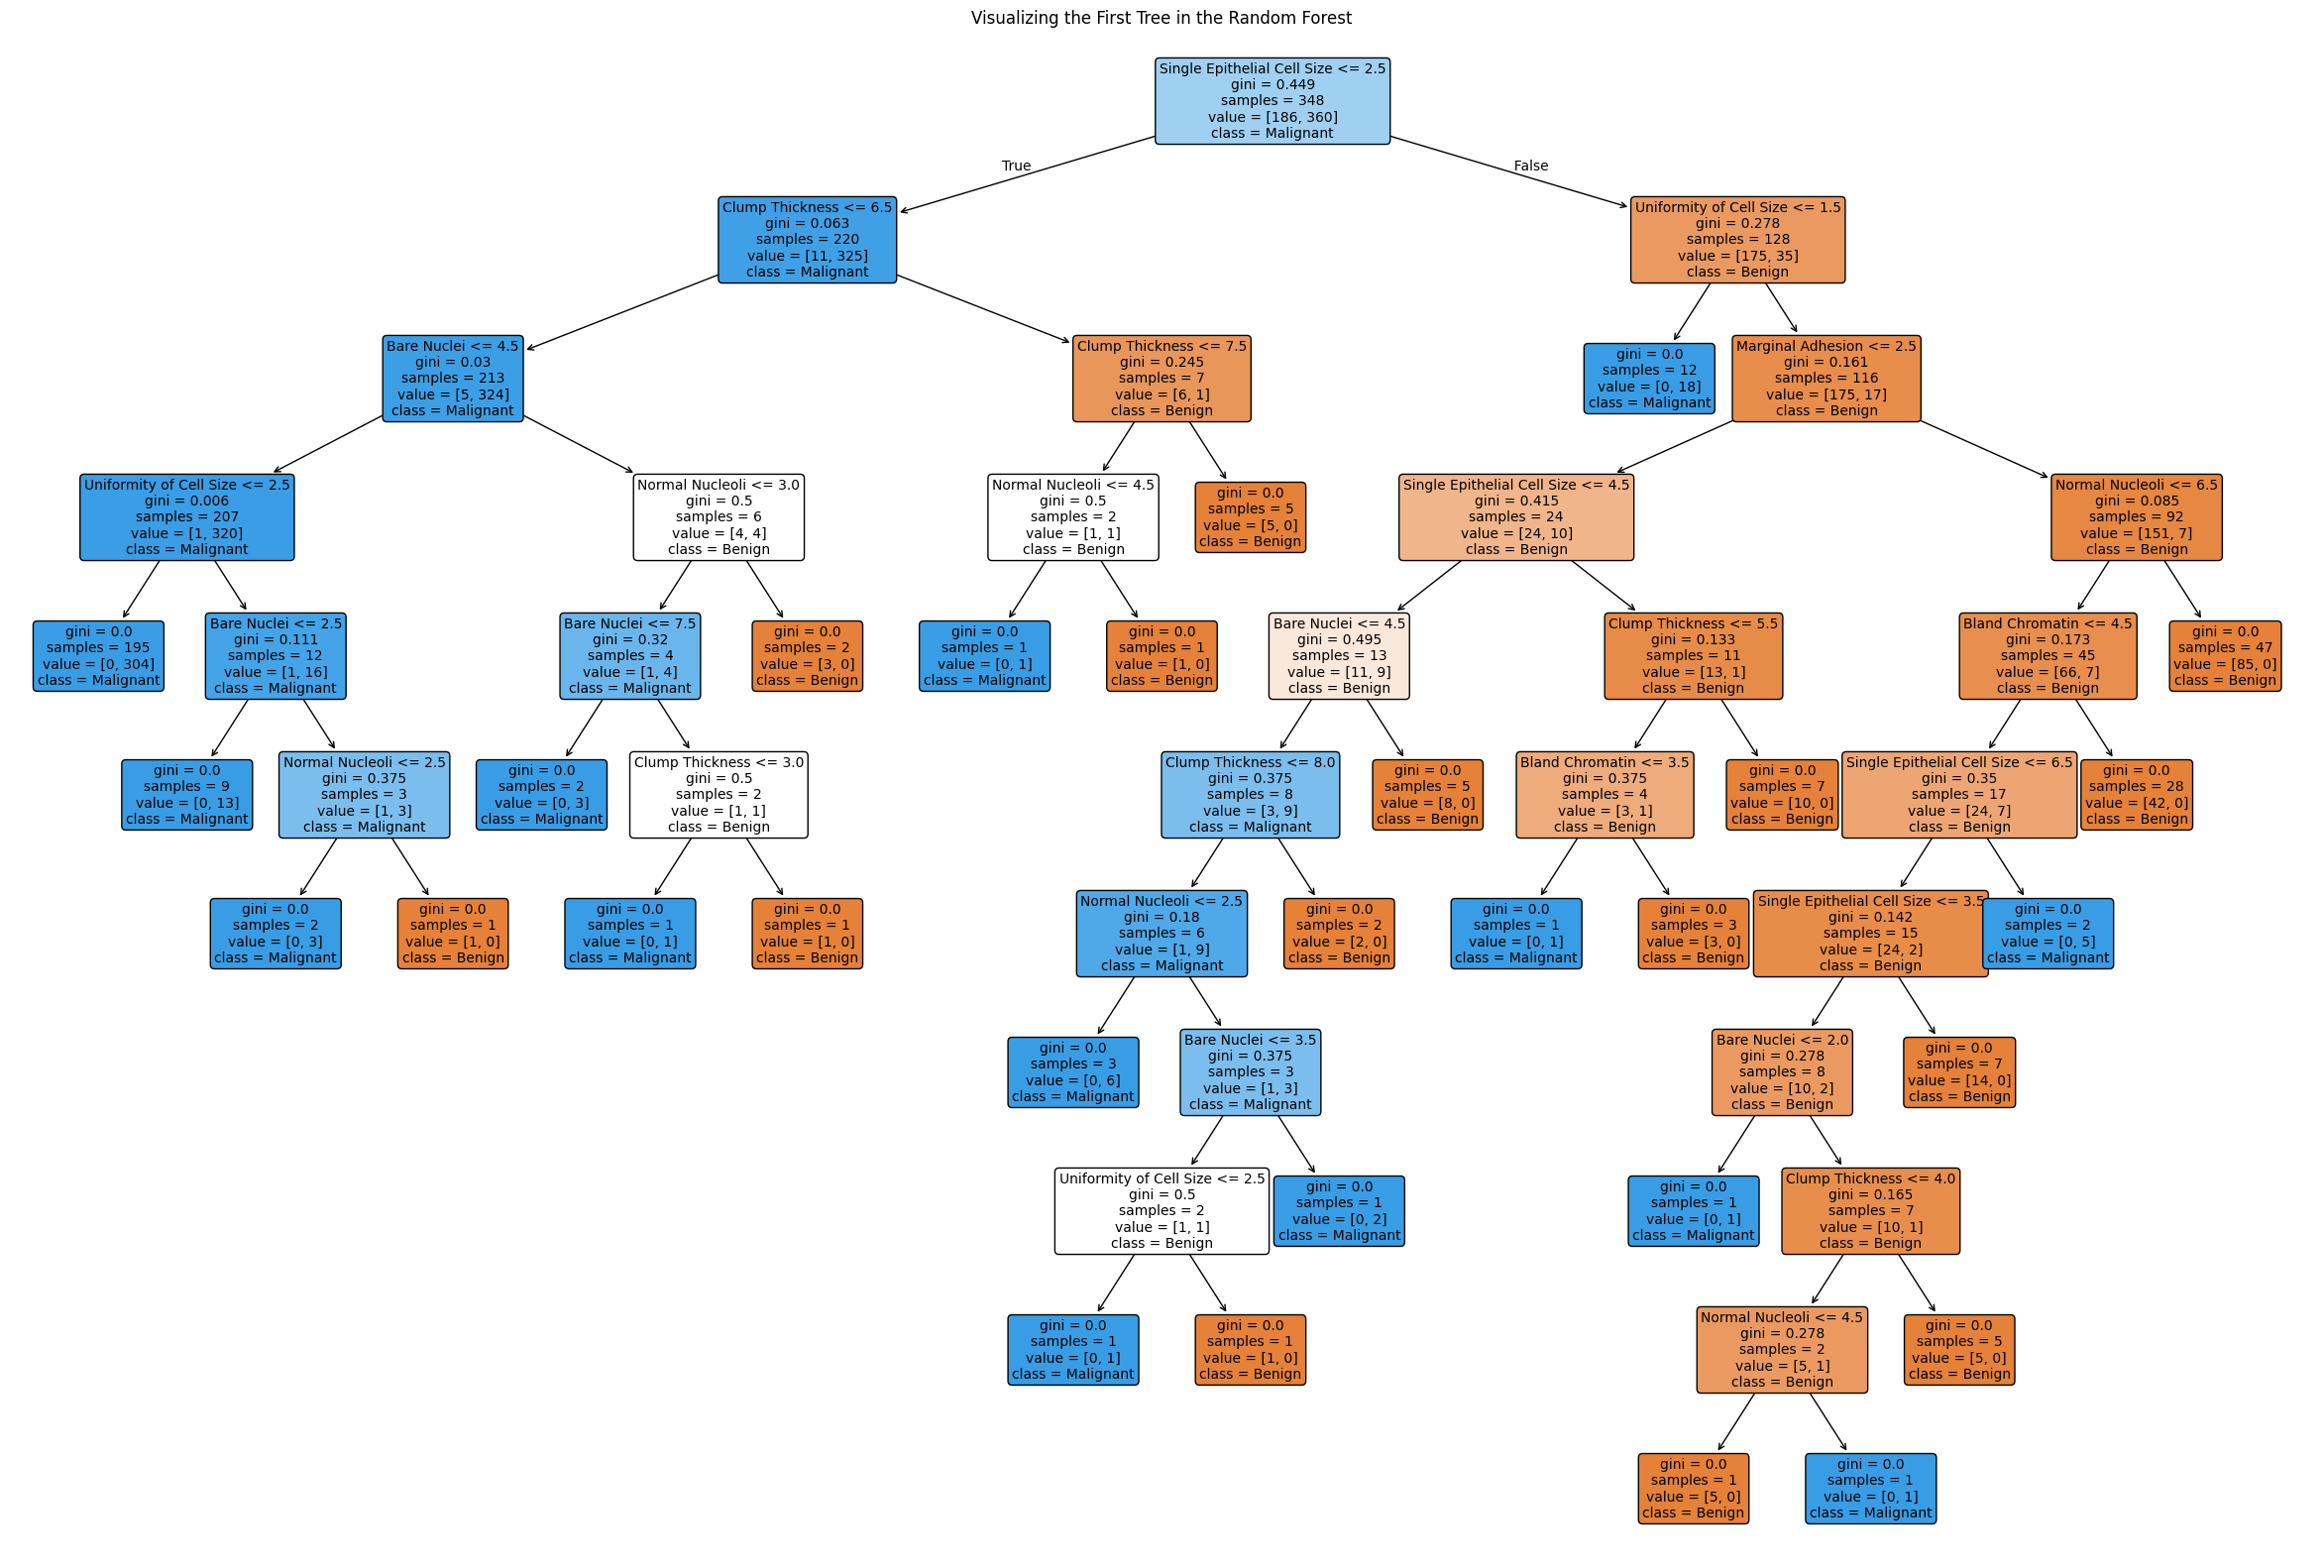

In [11]:

from sklearn.tree import plot_tree

# 1. Define your feature names again
feature_list = ['Clump Thickness', 'Uniformity of Cell Size', 'Marginal Adhesion', 
                'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 
                'Normal Nucleoli']

# 2. Pick ONE tree from your forest (e.g., the first one at index 0)
# Replace 'rf_model' with whatever you named your RandomForestClassifier
tree_to_plot = tree.estimators_[0] 

# 3. Visualize it
plt.figure(figsize=(30,20))
plot_tree(tree_to_plot, 
          feature_names=feature_list, 
          class_names=['Benign', 'Malignant'], 
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title("Visualizing the First Tree in the Random Forest")
plt.show()
